In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===============================================================
# 0️⃣ Imports and Setup
# ===============================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# ===============================
# Paths (Updated)
# ===============================

# Dataset path
BASE_PATH = "/content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/Rare_Split"

# Results path (inside your ResNet-50 folder)
RESULTS_PATH = "/content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result"

# Subfolders for saving results
TRAIN_RESULT = os.path.join(RESULTS_PATH, "train_val")
TEST_RESULT  = os.path.join(RESULTS_PATH, "test")
EVAL_RESULT  = os.path.join(RESULTS_PATH, "evaluation")

# Create directories
for p in [RESULTS_PATH, TRAIN_RESULT, TEST_RESULT, EVAL_RESULT]:
    os.makedirs(p, exist_ok=True)

print("BASE_PATH:", BASE_PATH)
print("RESULTS_PATH:", RESULTS_PATH)
print("Created result folders successfully.")


BASE_PATH: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/Rare_Split
RESULTS_PATH: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result
Created result folders successfully.


In [ ]:
# ===============================================================
# 1️⃣ Dataset and Transforms
# ===============================================================
img_size = 299
batch_size = 8

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(os.path.join(BASE_PATH, "train"), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(BASE_PATH, "val"), transform=eval_transform)
test_ds  = datasets.ImageFolder(os.path.join(BASE_PATH, "test"), transform=eval_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)
print(f"Train:{len(train_ds)}, Val:{len(val_ds)}, Test:{len(test_ds)}")

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)


Classes: ['Achyranthes aspera (Apang)', 'Alternanthera brasiliana L. kuntze (Kalochitra)', 'Andrographis paniculata wall. ex nees (Kalomegh)', 'Artocarpus chama (Chapalish)', 'Asparagus racemosus willd (Shotomuli)', 'Ayapana triplinervis (Ayapan)', 'Boerhavia diffusa L. (Punarnava)', 'Clerodendrum indicum L. kuntze (Bamonhati)', 'Datura tramonium L. (Kalodhutura)', 'Eleutherine bulbosa (Betal)', 'Gloriosa superba (Agnishikha)', 'Gynura procumbens (Lour.) merr. (Gainura)', 'Hemidesmus indicus (Linn.) R. Br (Anantamul)', 'Justicia adhatoda L. (Basok)', 'Ocimum gatissimum L. (Ram-Tulsi)', 'Rauwolfia serpentina (Sarpagandha)']
Train:2240, Val:480, Test:480


In [ ]:

# ===============================================================
# 2️⃣ Helper functions
# ===============================================================
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        images, labels = images.to(device), labels.to(device)
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        images, labels = images.to(device), labels.to(device)
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print(f"Epoch [{epoch+1}], train_loss: {result['train_loss']:.4f}, "
              f"val_loss: {result['val_loss']:.4f}, val_acc: {result['val_acc']:.4f}")

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)
    def __len__(self):
        return len(self.dl)

train_dl = DeviceDataLoader(train_dl, device)
val_dl   = DeviceDataLoader(val_dl, device)
test_dl  = DeviceDataLoader(test_dl, device)

In [ ]:
from torchvision.models import inception_v3, Inception_V3_Weights
import torch.nn as nn

# ===============================================================
# 3️⃣ Model Architecture (InceptionV3) — UPDATED
# ===============================================================
class InceptionV3Leaf(ImageClassificationBase):
    def __init__(self, num_classes):
        super().__init__()
        # Load pretrained InceptionV3 with aux_logits enabled (required for weights)
        self.model = inception_v3(
            weights=Inception_V3_Weights.DEFAULT,
            aux_logits=True
        )
        # Replace final fully connected layer for your num_classes
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, xb):
        outputs = self.model(xb)
        # During training, Inception returns (main, aux)
        # Only use main output to match training loop
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        return outputs

# ⚠️ Important: InceptionV3 expects 299x299 input images
# Make sure transforms.Resize((299, 299)) is applied

model = InceptionV3Leaf(num_classes).to(device)
print(model)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 155MB/s] 


InceptionV3Leaf(
  (model): Inception3(
    (Conv2d_1a_3x3): BasicConv2d(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_2a_3x3): BasicConv2d(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_2b_3x3): BasicConv2d(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (Conv2d_3b_1x1): BasicConv2d(
      (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_4a_3x3): B

In [ ]:
# ===============================================================
# 4️⃣ Training with Early Stopping + Train Accuracy Tracking (EfficientNet)
# ===============================================================
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)


def fit(model, train_loader, val_loader,
        max_epochs=50, lr=1e-4, patience=15, model_path=None):

    history = []
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_epoch = 0

    for epoch in range(max_epochs):

        model.train()
        train_losses = []
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            # Forward pass
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)
            train_losses.append(loss)

            # Accuracy tracking
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            # Backpropagation
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # Epoch metrics
        train_loss = torch.stack(train_losses).mean().item()
        train_acc = train_correct / train_total

        # Validation metrics
        val_result = evaluate(model, val_loader)
        val_result['train_loss'] = train_loss
        val_result['train_acc'] = train_acc

        # ---------- SAME PRINT STYLE AS RESNET + VIT ----------
        print(f"Epoch [{epoch+1}/{max_epochs}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_result['val_loss']:.4f}, Val Acc: {val_result['val_acc']:.4f}")
        # -------------------------------------------------------

        history.append(val_result)

        # Early stopping
        if val_result['val_loss'] < best_val_loss:
            best_val_loss = val_result['val_loss']
            best_epoch = epoch
            epochs_no_improve = 0

            if model_path:
                torch.save(model.state_dict(), model_path)
                print(f"✅ Best model saved at: {model_path} (Epoch {epoch+1})")

        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"⏹️ Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    print(f"🏁 Training stopped. Best epoch: {best_epoch+1} | val_loss: {best_val_loss:.4f}")
    return history


# ===============================================================
# ✅ Example Usage for EfficientNet
# ===============================================================
best_model_path_efficientnet = os.path.join(TRAIN_RESULT, "InceptionV3_leaf_best.pth")

history= fit(
    model,
    train_dl,
    val_dl,
    max_epochs=50,
    lr=1e-4,
    patience=15,
    model_path=best_model_path_efficientnet
)


Epoch [1/50] | Train Loss: 0.8267, Train Acc: 0.8196 | Val Loss: 0.0442, Val Acc: 0.9937
✅ Best model saved at: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result/train_val/efficientnet_leaf_best.pth (Epoch 1)
Epoch [2/50] | Train Loss: 0.1721, Train Acc: 0.9621 | Val Loss: 0.0423, Val Acc: 0.9917
✅ Best model saved at: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result/train_val/efficientnet_leaf_best.pth (Epoch 2)
Epoch [3/50] | Train Loss: 0.0994, Train Acc: 0.9790 | Val Loss: 0.0863, Val Acc: 0.9833
Epoch [4/50] | Train Loss: 0.1126, Train Acc: 0.9696 | Val Loss: 0.0233, Val Acc: 0.9937
✅ Best model saved at: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result/train_val/efficientnet_leaf_best.pth (Epoch 4)
Epoch [5/50] | Train Loss: 0.0696, Train Acc: 0.9857 | Val Loss: 0.0075, Val Acc: 0.9979
✅ Best model saved at: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result/train_val/efficientnet

In [ ]:
import json
import os

# ============================
# 1️⃣ Save Training History
# ============================
def save_history_json(history, save_path):
    clean_history = []
    for h in history:
        clean_history.append({
            "train_loss": float(h["train_loss"]),
            "val_loss": float(h["val_loss"]),
            "train_acc": float(h["train_acc"]) if "train_acc" in h else None,
            "val_acc": float(h["val_acc"]) if "val_acc" in h else None
        })

    with open(save_path, "w") as f:
        json.dump(clean_history, f, indent=4)

    print(f"📁 History saved: {save_path}")


history_json_path_vit = os.path.join(TRAIN_RESULT, "history_InceptionV3.json")
save_history_json(history, history_json_path_vit)



📁 History saved: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result/train_val/history_efficientNetB0.json


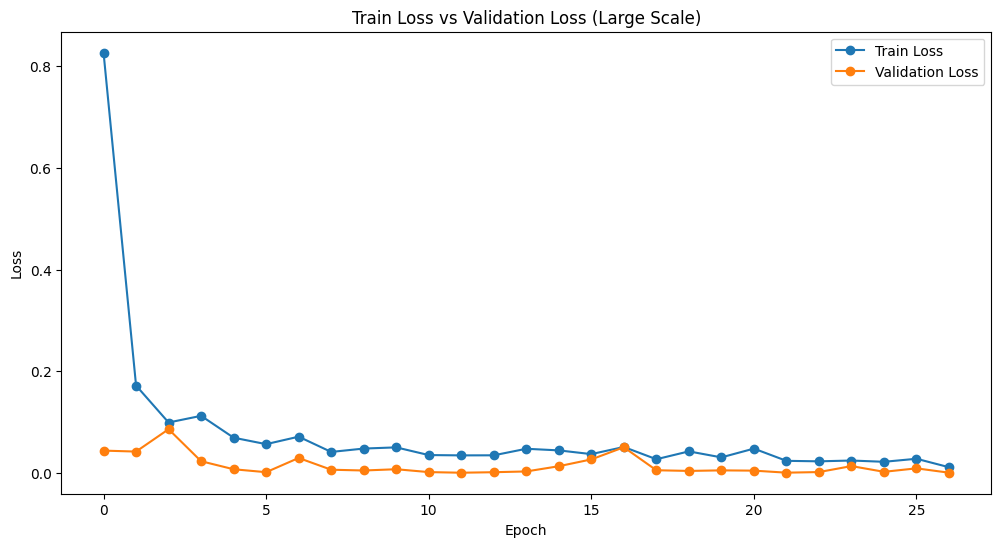

📈 Loss graph saved: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result/train_val/loss_only_graph.png


In [ ]:

# ==============================================
# 2️⃣ Plot Train Loss vs Val Loss (Large Graph)
# ==============================================
def plot_loss_graph(history, save_dir):
    train_losses = [x['train_loss'] for x in history]
    val_losses = [x['val_loss'] for x in history]

    plt.figure(figsize=(12,6))
    plt.plot(train_losses, label="Train Loss", marker="o")
    plt.plot(val_losses, label="Validation Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train Loss vs Validation Loss (Large Scale)")
    plt.legend()
    save_path = os.path.join(save_dir, "loss_only_graph.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"📈 Loss graph saved: {save_path}")


plot_loss_graph(history, TRAIN_RESULT)


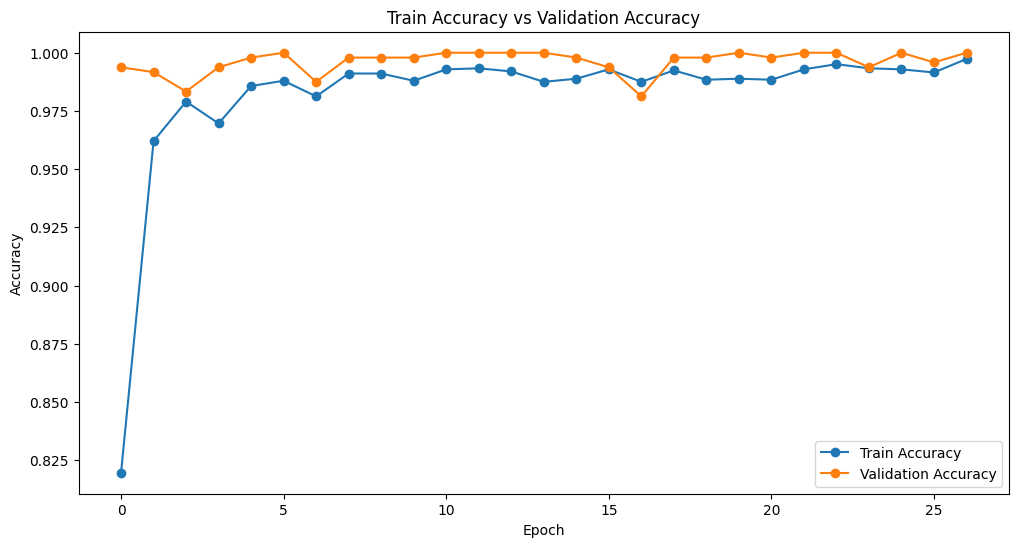

📈 Accuracy graph saved: /content/drive/My Drive/4_2/ML-4-2/ML-Data/DatasetFinal/InceptionV3/result/train_val/accuracy_graph.png


In [ ]:
# ==============================================
# 3️⃣ Plot Train Accuracy vs Val Accuracy
# ==============================================
def plot_accuracy_graph(history, save_dir):
    train_acc = [x['train_acc'] for x in history] if "train_acc" in history[0] else None
    val_acc = [x['val_acc'] for x in history]

    plt.figure(figsize=(12,6))

    if train_acc:
        plt.plot(train_acc, label="Train Accuracy", marker="o")

    plt.plot(val_acc, label="Validation Accuracy", marker="o")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Train Accuracy vs Validation Accuracy")
    plt.legend()
    save_path = os.path.join(save_dir, "accuracy_graph.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"📈 Accuracy graph saved: {save_path}")


plot_accuracy_graph(history, TRAIN_RESULT)


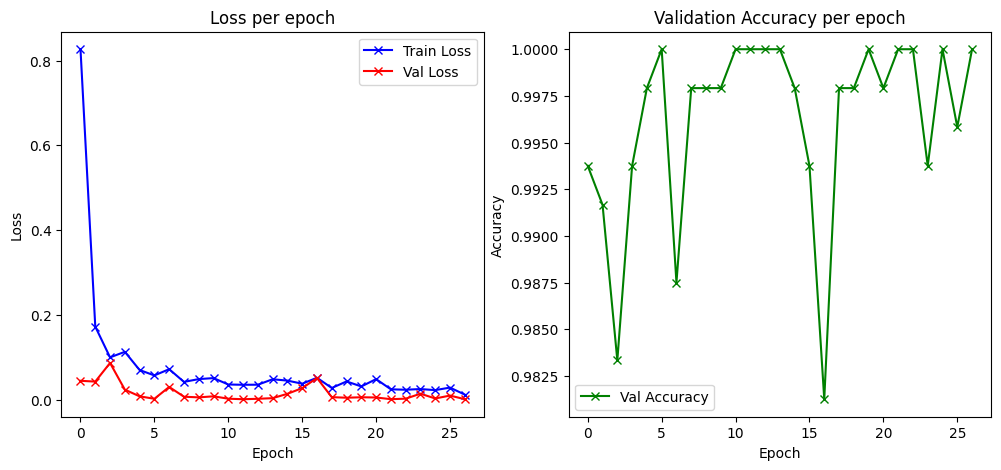

In [ ]:
# ===============================================================
# 5️⃣ Plot Loss & Accuracy
# ===============================================================
def plot_history(history, save_path):
    train_losses = [x['train_loss'] for x in history]
    val_losses = [x['val_loss'] for x in history]
    val_acc = [x['val_acc'] for x in history]

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, '-bx', label="Train Loss")
    plt.plot(val_losses, '-rx', label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss per epoch")

    plt.subplot(1,2,2)
    plt.plot(val_acc, '-gx', label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy per epoch")
    plt.legend()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_history(history, os.path.join(TRAIN_RESULT, "train_val_history.png"))

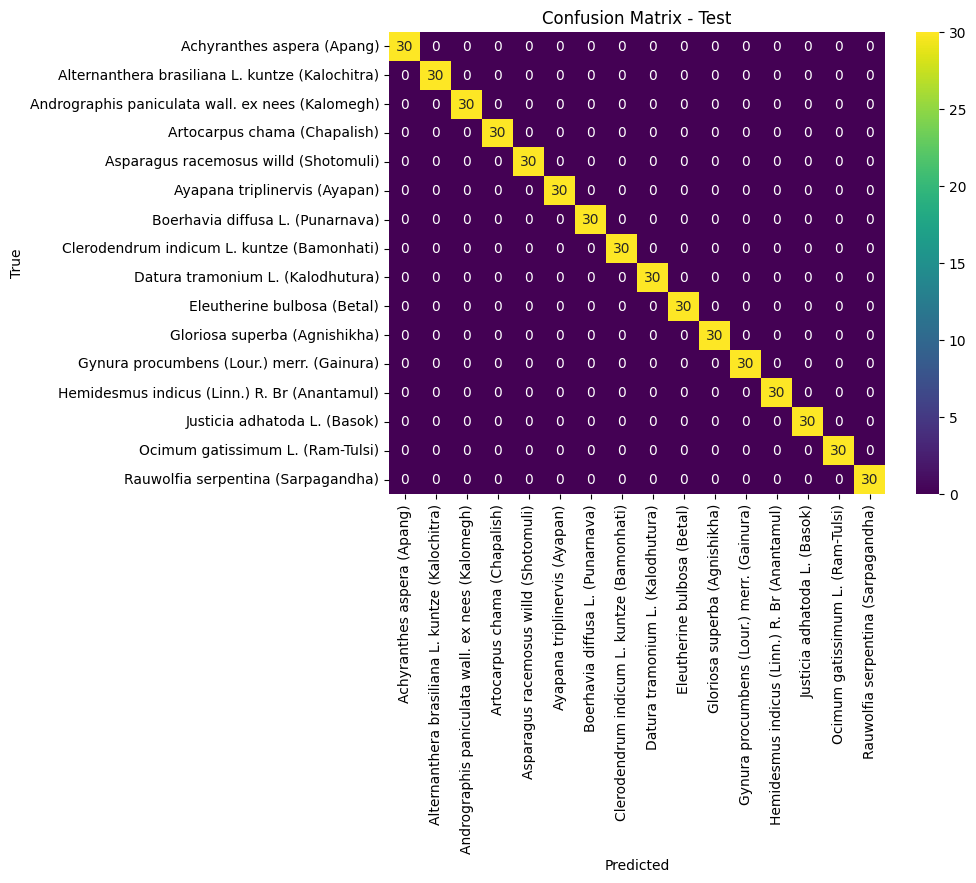

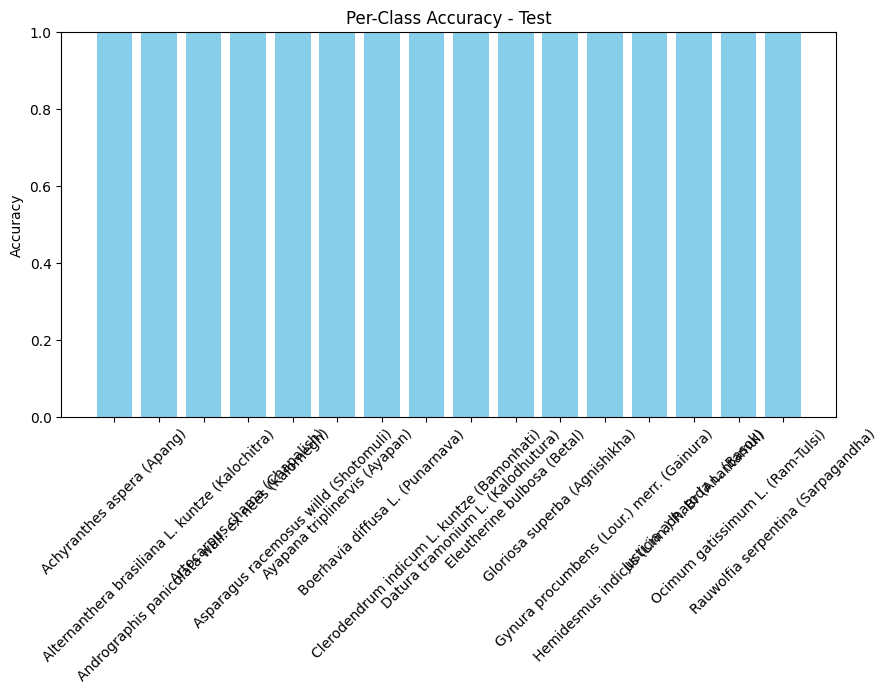

In [ ]:

# ===============================================================
# 6️⃣ Test Evaluation + Confusion Matrix + Classification Report
# ===============================================================
@torch.no_grad()
def evaluate_test(model, test_loader, class_names, save_path):
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test")
    plt.savefig(os.path.join(save_path, "confusion_matrix_test.png"), dpi=300)
    plt.show()
    print("\n")  # 👈 add spacing after confusion matrix

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join(save_path, "classification_report_test.csv"))

    # Per-class accuracy
    per_class_acc = np.diag(cm) / cm.sum(axis=1)
    plt.figure(figsize=(10,5))
    plt.bar(class_names, per_class_acc, color='skyblue')
    plt.xticks(rotation=45)
    plt.ylim(0,1)
    plt.ylabel("Accuracy")
    plt.title("Per-Class Accuracy - Test")
    plt.savefig(os.path.join(save_path, "per_class_accuracy.png"), dpi=300)
    plt.show()
    print("\n")  # 👈 add spacing after confusion matrix

evaluate_test(model, test_dl, class_names, EVAL_RESULT)

# ✅ All results, best model, plots, and evaluation are saved locally
